In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import openpyxl
# !pip install pandas
# !pip install openpyxl

In [2]:
df = pd.read_csv("fitness_synthetic_dataset.csv")

In [3]:
df

,timestamp,heart_rate,steps,sleep_hours
0,2026-01-01 00:00:00,47.2,0.0,6.60
1,2026-01-01 00:01:00,59.5,0.0,7.20
2,2026-01-01 00:02:00,60.5,0.0,6.55
3,2026-01-01 00:03:00,62.3,0.0,7.52
4,2026-01-01 00:04:00,51.7,0.0,5.77
...,...,...,...,...
1995,2026-01-02 09:15:00,83.6,26.0,0.00
1996,2026-01-02 09:16:00,74.8,19.0,0.00
1997,2026-01-02 09:17:00,67.9,22.0,0.00
1998,2026-01-02 09:18:00,73.7,26.0,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    2000 non-null   object 
 1   heart_rate   1950 non-null   float64
 2   steps        1950 non-null   float64
 3   sleep_hours  2000 non-null   float64
dtypes: float64(3), object(1)
memory usage: 62.6+ KB


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2000 entries, 2026-01-01 00:00:00 to 2026-01-02 09:19:00
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   heart_rate   1950 non-null   float64
 1   steps        1950 non-null   float64
 2   sleep_hours  2000 non-null   float64
dtypes: float64(3)
memory usage: 62.5 KB


In [7]:
df.isnull().sum()

heart_rate     50
steps          50
sleep_hours     0
dtype: int64

In [8]:
print((df.isnull().sum() / len(df)) * 100)

heart_rate     2.5
steps          2.5
sleep_hours    0.0
dtype: float64


In [9]:
df.shape

(2000, 3)

In [10]:
df['heart_rate'] = df['heart_rate'].interpolate()
df['steps'] = df['steps'].interpolate()

In [11]:
df.isnull().sum()

heart_rate     0
steps          0
sleep_hours    0
dtype: int64

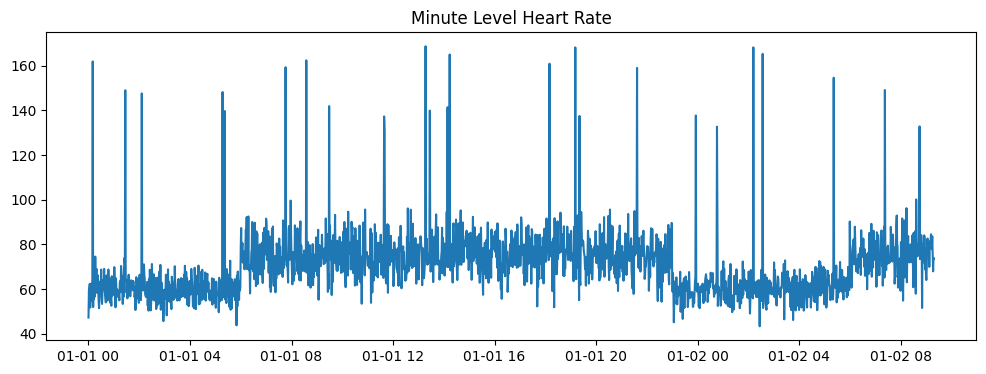

In [12]:
plt.figure(figsize = (12,4))
plt.plot(df.index, df['heart_rate'])
plt.title("Minute Level Heart Rate")
plt.show()

In [13]:
df_hourly = df.resample('h').mean()

In [14]:
print("Original rows:", len(df))
print("Hourly rows:", len(df_hourly))

Original rows: 2000
Hourly rows: 34


In [15]:
df_hourly['hr_rolling_mean'] = df_hourly['heart_rate'].rolling(window=24).mean()

In [16]:
df_hourly['z_score'] = stats.zscore(df_hourly['heart_rate'])
df_hourly['anomaly'] = df_hourly['z_score'].abs() > 2

In [1]:
plt.figure(figsize=(12,5))
plt.plot(df_hourly.index, df_hourly['heart_rate'], label='Heart Rate')

plt.scatter(
    df_hourly[df_hourly['anomaly']].index,
    df_hourly[df_hourly['anomaly']]['heart_rate'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Hourly Heart Rate with Anomalies")
plt.show()


NameError: name 'plt' is not defined

In [4]:
plt.figure(figsize=(12,4))
plt.plot(df['heart_rate'], alpha=0.4, label='Minute')
plt.plot(df_hourly['heart_rate'],linewidth=2,label='Hourly')
plt.legend()
plt.title("Minute vs Hourly heart rate")
plt.show()

NameError: name 'df' is not defined

<Figure size 1200x400 with 0 Axes>